# Corporacion Favorita - New Superb Forecasting Model - 

## Split and Model Pipeline

#codi

Made by 4B Consultancy (Janne Heuvelmans, Georgi Duev, Alexander Engelage, Sebastiaan de Bruin) - 2024

In this data pipeline, 

The following steps are made within this notebook:  

>-0. Import Packages 

>-1. Load final dataset and aggregate dataset to weekly level
    -1.1 Load final dataset made in Data Preperation Pipeline Notebook
    -1.2 Aggregate dataset to weekly level

>-2. Column transformers and Train, Test, Validation Split

>-3. Models

>-4. Pick best model one and optimize with grid search

## 0. Import Packages

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import polars as pl
import os
import sys
import altair as alt
import vegafusion as vf
import sklearn
import time
from datetime import date, datetime, timedelta
from sklearn.pipeline import Pipeline, make_pipeline

In [2]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_absolute_percentage_error

import statsmodels.api as sm

In [3]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [4]:
from sktime.forecasting.compose import EnsembleForecaster

## 1. Load final dataset

### 1.1. Functions - Import raw data from local PATH
Create import data function and give basic information function within the importing function.

Return basic information on each dataframe:  
- a) Information on the number of observation and features.  
- b) Information on the size of the dataframe. 

TO-DO: Import via polars, and use polars dataframe?

In [5]:
def f_get_data_and_info(import_path, file_name):

    print(f"\nReading file {file_name}\n")

    # Load data.
    df = pd.read_parquet(import_path + file_name + ".parquet")

    # Getting the basic information of the dataframe (number of observations and features, and size)
    print(
        f"The '{file_name}' dataframe contains: {df.shape[0]:,}".replace(",", ".")
        + f" observations and {df.shape[1]} features."
    )
    print(
        f"Prepared and transformed dataframe has optimized size of {round(sys.getsizeof(df)/1024/1024/1024, 2)} GB."
    )

    return df

### 1.2. Importing raw data
Importing parquet files with importing function (giving basic information)

In [6]:
import_path = "C:/Users/alexander/Documents/0. Data Science and AI for Experts/FILE/"

# Importing final df
df_final = f_get_data_and_info(import_path, file_name="Prepped_data_20241101")


Reading file Prepped_data_20241101

The 'Prepped_data_20241101' dataframe contains: 59.021.382 observations and 19 features.
Prepared and transformed dataframe has optimized size of 2.36 GB.


To-do: include null_count print dunction into importing OR make basic descrption function with features, size, null_count

In [7]:
df_final.info()
# Count nulls per column
null_counts = df_final.isnull().sum()

# Print results
for column, count in null_counts.items():
    print(f"Column '{column}' has {count} null values.")

<class 'pandas.core.frame.DataFrame'>
Index: 59021382 entries, 0 to 59021381
Data columns (total 19 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   store_nbr               uint8         
 1   item_nbr                uint32        
 2   date                    datetime64[ns]
 3   unit_sales              float32       
 4   onpromotion             bool          
 5   holiday_local_count     int8          
 6   holiday_national_count  int8          
 7   holiday_regional_count  int8          
 8   store_type              category      
 9   store_cluster           uint8         
 10  item_family             category      
 11  item_class              uint16        
 12  perishable              uint8         
 13  store_status            int8          
 14  item_status             int8          
 15  year                    int16         
 16  weekday                 int8          
 17  week_nbr                int8          
 18  week_

## 2.0 Train val test split

SKtime

ExpandingWindowSplitter


#TO-DO: Selecting on weeks or via data?

train_val_test_split without creating X (features) and y (target)

In [8]:
def train_val_test_split(df, window_length=26):

    # Sort the DataFrame by store number, item number, and date for ordering
    df = df.sort_values(["store_nbr", "item_nbr", "week_number_cum"])

    # Get the maximum week in the dataset
    max_week = df["week_number_cum"].max()

    # Calculate start and end weeks for validation and test sets
    test_week_start = max_week - window_length + 1

    val_week_start = max_week - 2 * window_length + 1

    val_week_end = test_week_start - 1

    train_week_end = val_week_start - 1

    # Train data: All data before the start of the validation period
    train = df[df["week_number_cum"] <= train_week_end]

    # Val data: From `val_week_start` to `val_week_end`
    val = df[
        (df["week_number_cum"] >= val_week_start)
        & (df["week_number_cum"] <= val_week_end)
    ]

    # Test data: From `test_week_start` to `max_week`
    test = df[
        (df["week_number_cum"] >= test_week_start) & (df["week_number_cum"] <= max_week)
    ]

    # Function to print split information
    def print_split_info(split_name, split):
        print(f"\n{split_name} set: shape: {split.shape}")
        print(f"{split_name} Min Week: {split['week_number_cum'].min()}")
        print(f"{split_name} Max Week: {split['week_number_cum'].max()}")
        print(f"{split_name} number of weeks: {split['week_number_cum'].nunique()}")
        print(f"Number of stores: {split['store_nbr'].nunique()}")
        print(f"Number of items: {split['item_nbr'].nunique()}")
        print(f"Size of {round(sys.getsizeof(split)/1024/1024/1024, 2)} GB.")

    # Print information about the splits
    print_split_info("Train", train)
    print_split_info("Validation", val)
    print_split_info("Test", test)

    return train, val, test

In [9]:
# train, val, test = train_val_test_split(df_final, window_length=26)

## 3.0 Functions - Impute stockouts and Aggregate dataset to weekly level


#### 3.1. Impute stockouts

Stockout on store level

•      Perishable good: when there are missing values for two consecutive days for a given item per individual store 

•      Nonperishable goods: when there are missing values for 7 consecutive days for a given item and per individual store

•      Action: Impute with Rolling Mean with defeault window of 7 days 

------------------------------------

In [ ]:
def impute_stockouts_polars(df_pandas, window_size=7):

    # Convert the input Pandas DataFrame to a Polars DataFrame
    df = pl.from_pandas(df_pandas)

    # Sort the DataFrame by store number, item number, and date for ordering

    df = df.sort(["store_nbr", "item_nbr", "date"])

    # Nested function calc_missing_count to calculate the count of consecutive missing values in unit_sales

    def calc_missing_count(unit_sales):

        return (
            unit_sales.is_null()  # Check for null values
            .cast(pl.Int32)  # Cast to integer (1 for null, 0 for not null)
            .cum_sum()  # Cumulative sum to count sequential nulls
            .over(["store_nbr", "item_nbr"])  # Group by store_nbr and item_nbr
        )

    # Nested function to Inpute with rolling mean for missing values
    def rolling_mean_imputation(unit_sales, window_size):

        return (
            unit_sales.rolling_mean(
                window_size=window_size, min_periods=1
            )  # Impute strategy based on rolling mean
            .shift(
                1
            )  # Shift window by one day, to prevent taking the same day into account
            .over(["store_nbr", "item_nbr"])  # Group by store_nbr and item_nbr
        )

    # Apply the imputation logic based on the perishable status of the items

    df = df.with_columns(
        [
            pl.when(pl.col("perishable") == 1)  # Check if the item is perishable = 1
            .then(
                pl.when(
                    calc_missing_count(pl.col("unit_sales")) == 1
                )  # 1 missing value
                .then(0)  # --> Impute with 0
                .when(
                    calc_missing_count(pl.col("unit_sales")) > 2
                )  # More than 2 missing values
                .then(0)  # --> Impute with 0
                .when(
                    calc_missing_count(pl.col("unit_sales")) == 2
                )  # = 2 missing values
                .then(
                    rolling_mean_imputation(pl.col("unit_sales"), window_size)
                )  # --> Inpute with rolling mean for 2 missing days
                .otherwise(pl.col("unit_sales"))  # Otherwise keep original value
            )
            .when(pl.col("perishable") == 0)  # If the item is not perishable = 0
            .then(
                pl.when(
                    calc_missing_count(pl.col("unit_sales")) > 7
                )  # More than 7 missing values
                .then(0)  # --> Impute with 0
                .when(
                    calc_missing_count(pl.col("unit_sales")) <= 7
                )  # if less 7 missing values
                .then(
                    rolling_mean_imputation(pl.col("unit_sales"), window_size)
                )  # --> Inpute with rolling mean for missing 7 or less days
                .otherwise(pl.col("unit_sales"))  # Otherwise keep original value
            )
            .otherwise(pl.col("unit_sales"))  # For any other case not covered
            .alias("unit_sales")  # Alias the new column as 'unit_sales'
        ]
    )

    df = 
    
    # Convert Polars df back to Pandas df
    df = df.to_pandas()

    return df

## DEBUG
 ----------------------------------------------

In [11]:
# ["perishable"] == 0
df_final_10_103520 = df_final[
    (df_final["store_nbr"] == 10) & (df_final["item_nbr"] == 103520)
]

df_final_10_103520.head(1)

,store_nbr,item_nbr,date,unit_sales,onpromotion,holiday_local_count,holiday_national_count,holiday_regional_count,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status,year,weekday,week_nbr,week_number_cum
12647439,10,103520,2013-01-02,NaN,False,0,0,0,C,15,GROCERY I,1028,0,0,3,2013,3,1,1


In [12]:
# ["perishable"] == 1
df_final_10_1149579 = df_final[
    (df_final["store_nbr"] == 10) & (df_final["item_nbr"] == 1149579)
]

df_final_10_1149579.head(1)

,store_nbr,item_nbr,date,unit_sales,onpromotion,holiday_local_count,holiday_national_count,holiday_regional_count,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status,year,weekday,week_nbr,week_number_cum
13445390,10,1149579,2013-01-02,NaN,False,0,0,0,C,15,BREAD/BAKERY,2708,1,0,3,2013,3,1,1


In [105]:
df_final_10_103520_1149579 = df_final[
    (df_final["store_nbr"] == 10) & (df_final["item_nbr"].isin([103520, 1149579]))
]

In [14]:
# save_dataframe_to_csv(
#     df_final_10_103520_1149579_imputed,
#     output_path,
#     "df_final_10_103520_1149579_imputed",
# )

In [ ]:
def impute_stockouts_polars_new(df_pandas, window_size=7):
    # Convert the input Pandas DataFrame to a Polars DataFrame
    df = pl.from_pandas(df_pandas)

    # Sort the DataFrame by store number, item number, and date for proper ordering
    df = df.sort(["store_nbr", "item_nbr", "date"])

    # Create a boolean column to indicate where 'unit_sales' is missing
    df = df.with_columns((pl.col("unit_sales").is_null()).alias("is_missing"))

    # Assign a group identifier to each segment of missing or non-missing values
    df = df.with_columns(
        (
            pl.col("is_missing").cast(pl.Int16)
            != pl.col("is_missing").cast(pl.Int16).shift(1)
        )
        .cast(pl.Int16)
        .cum_sum()
        .alias("missing_group")
        .cast(pl.Int32)
    )

    # Calculate cumulative count of missing values within each segment of missing data
    df = df.with_columns(
        pl.when(pl.col("is_missing"))
        .then(
            pl.col("is_missing")
            .cast(pl.Int16)
            .cum_sum()
            .over(["store_nbr", "item_nbr", "missing_group"])
        )
        .otherwise(0)
        .alias("missing_count")
    )

    # Identify groups to find maximum of the same missing_count group
    df = df.with_columns(
        pl.col("missing_count")
        .max()
        .over(["missing_group"])
        .alias("group_max_missing_count")
        .cast(pl.Int16)
    )

    # Function for rolling mean imputation
    def rolling_mean_imputation(df, window_size=7):
        # Add rolling mean column for grouped data
        df = df.with_columns(
            pl.col("unit_sales")
            .rolling_mean(window_size=window_size, min_periods=1)
            .over(["store_nbr", "item_nbr"])
            .shift(1)  # Shift to exclude current row
            .alias("unit_sales_rolling_mean")
        )

        # Replace nulls in the target column with the calculated rolling mean
        df = df.with_columns(
            pl.when(pl.col("unit_sales").is_null())
            .then(pl.col("unit_sales_rolling_mean"))
            .otherwise(pl.col("unit_sales"))
            .alias("unit_sales")
        )

        # Drop the temporary rolling mean column
        df = df.drop("unit_sales_rolling_mean")

        return df

    # Apply rolling mean imputation based on perishable status
    df = df.with_columns(
        [
            pl.when(pl.col("perishable") == 1)  # If the item is perishable
            .then(
                pl.when(pl.col("group_max_missing_count") == 1)  # 1 missing value
                .then(0)  # Impute with 0
                .when(
                    pl.col("group_max_missing_count") > 2
                )  # More than 2 missing values
                .then(0)  # Impute with 0
                .when(
                    pl.col("group_max_missing_count") == 2
                )  # Exactly 2 missing values
                .then(
                    rolling_mean_imputation(df, window_size=7)["unit_sales"]
                )  # Impute with rolling mean for 2 missing days
                .otherwise(pl.col("unit_sales"))  # Keep original value
            )
            .when(pl.col("perishable") == 0)  # If the item is not perishable
            .then(
                pl.when(
                    pl.col("group_max_missing_count") > 7
                )  # More than 7 missing values
                .then(0)  # Impute with 0
                .when(
                    pl.col("group_max_missing_count") <= 7
                )  # 7 or fewer missing values
                .then(
                    rolling_mean_imputation(df, window_size=7)["unit_sales"]
                )  # Impute with rolling mean for missing 7 or fewer days
                .otherwise(pl.col("unit_sales"))  # Keep original value
            )
            .otherwise(pl.col("unit_sales"))  # For other cases, keep the original value
            .alias("unit_sales")
        ]
    )

    df = df.drop(
        "is_missing", "missing_group", "missing_count", "group_max_missing_count"
    )

    # Convert Polars df back to Pandas df
    df = df.to_pandas()

    return df

In [109]:
df_final_10_103520_1149579_imputed = impute_stockouts_polars_new(
    df_final_10_103520_1149579, window_size=7
)

In [110]:
df_final_10_103520_1149579_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3374 entries, 0 to 3373
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   store_nbr                3374 non-null   uint8         
 1   item_nbr                 3374 non-null   uint32        
 2   date                     3374 non-null   datetime64[ns]
 3   unit_sales               3370 non-null   float32       
 4   onpromotion              3374 non-null   bool          
 5   holiday_local_count      3374 non-null   int8          
 6   holiday_national_count   3374 non-null   int8          
 7   holiday_regional_count   3374 non-null   int8          
 8   store_type               3374 non-null   category      
 9   store_cluster            3374 non-null   uint8         
 10  item_family              3374 non-null   category      
 11  item_class               3374 non-null   uint16        
 12  perishable               3374 non-

In [99]:
df_final_10_103520_1149579_imputed.tail(5)

,store_nbr,item_nbr,date,unit_sales,onpromotion,holiday_local_count,holiday_national_count,holiday_regional_count,store_type,store_cluster,...,store_status,item_status,year,weekday,week_nbr,week_number_cum,is_missing,missing_group,missing_count,group_max_missing_count
3369,10,1149579,2017-08-11,0.0,False,0,1,0,C,15,...,0,1,2017,5,32,241,True,1062.0,1,3
3370,10,1149579,2017-08-12,0.0,False,0,0,0,C,15,...,0,1,2017,6,32,241,True,1062.0,2,3
3371,10,1149579,2017-08-13,0.0,False,0,0,0,C,15,...,0,1,2017,7,32,241,True,1062.0,3,3
3372,10,1149579,2017-08-14,2.0,False,0,0,0,C,15,...,0,1,2017,1,33,242,False,1063.0,0,0
3373,10,1149579,2017-08-15,2.0,False,0,0,0,C,15,...,0,1,2017,2,33,242,False,1063.0,0,0


In [78]:
df_final_10_103520_1149579_imputed.head(5)

,store_nbr,item_nbr,date,unit_sales,onpromotion,holiday_local_count,holiday_national_count,holiday_regional_count,store_type,store_cluster,...,store_status,item_status,year,weekday,week_nbr,week_number_cum,is_missing,missing_group,missing_count,group_max_missing_count
0,10,103520,2013-01-02,NaN,False,0,0,0,C,15,...,0,3,2013,3,1,1,True,NaN,1,1
1,10,103520,2013-01-03,NaN,False,0,0,0,C,15,...,0,3,2013,4,1,1,True,0.0,1,3
2,10,103520,2013-01-04,NaN,False,0,0,0,C,15,...,0,3,2013,5,1,1,True,0.0,2,3
3,10,103520,2013-01-05,NaN,False,0,1,0,C,15,...,0,3,2013,6,1,1,True,0.0,3,3
4,10,103520,2013-01-06,2.0,False,0,0,0,C,15,...,0,1,2013,7,1,1,False,1.0,0,0


In [90]:
df_pandas = df_final_10_103520_1149579

df_polars = pl.from_pandas(df_pandas)


def calc_missing_count(df):

    # Create a boolean column to indicate where 'unit_sales' is missing
    df = df.with_columns((pl.col("unit_sales").is_null()).alias("is_missing"))

    # Assign a group identifier to each segment of missing or non-missing values
    df = df.with_columns(
        (
            pl.col("is_missing").cast(pl.Int16)
            != pl.col("is_missing").cast(pl.Int32).shift(1)
        )
        .cast(pl.Int32)
        .cum_sum()
        .alias("missing_group")
    )

    # Calculate cumulative count of missing values within each segment of missing data
    df = df.with_columns(
        pl.when(pl.col("is_missing"))
        .then(
            pl.col("is_missing")
            .cast(pl.Int32)
            .cum_sum()
            .over(["store_nbr", "item_nbr", "missing_group"])
        )
        .otherwise(0)
        .alias("missing_count")
    )

    return df


# Apply the revised function to create a new 'missing_count' column
df_polars = calc_missing_count(df_polars)

# Convert back to pandas to visualize the result
df_with_missing_count = df_polars.to_pandas()

In [92]:
df_with_missing_count_cleaned = df_with_missing_count[
    ["store_nbr", "item_nbr", "date", "unit_sales", "missing_count", "missing_group"]
].sort_values(["item_nbr", "date", "missing_count"])

df_final_10_103520_1149579_imputed_cleaned = df_final_10_103520_1149579_imputed[
    [
        "store_nbr",
        "item_nbr",
        "date",
        "unit_sales",
        "perishable",
    ]
].sort_values(
    [
        "item_nbr",
        "date",
    ]
)

In [ ]:
merged_df = pd.merge(
    df_with_missing_count_cleaned,
    df_final_10_103520_1149579_imputed_cleaned,
    on=["store_nbr", "item_nbr", "date"],
    how="outer",
)  # Use outer join to keep all records

# Sort the merged DataFrame
sorted_merged_df = merged_df.sort_values(
    by=["item_nbr", "date"], ascending=[True, True]
)


sorted_merged_df.head(30)

,store_nbr,item_nbr,date,unit_sales_x,missing_count,missing_group,unit_sales_y,perishable
0,10,103520,2013-01-02,NaN,1,0.0,NaN,0
1,10,103520,2013-01-03,NaN,2,0.0,NaN,0
2,10,103520,2013-01-04,NaN,3,0.0,NaN,0
3,10,103520,2013-01-05,NaN,4,0.0,NaN,0
4,10,103520,2013-01-06,2.0,0,1.0,2.0,0
5,10,103520,2013-01-07,NaN,1,2.0,2.0,0
6,10,103520,2013-01-08,NaN,2,2.0,2.0,0
7,10,103520,2013-01-09,2.0,0,3.0,2.0,0
8,10,103520,2013-01-10,NaN,1,4.0,2.0,0
9,10,103520,2013-01-11,3.0,0,5.0,3.0,0


In [ ]:
def plot_unit_sales_vs_missing_count(df):
    # Scatter plot of unit sales vs. missing count
    plt.figure(figsize=(10, 6))
    plt.scatter(df["missing_count"], df["unit_sales"], alpha=0.6)
    plt.xlabel("Missing Count")
    plt.ylabel("Unit Sales")
    plt.title("Scatter Plot: Unit Sales vs. Missing Count")
    plt.grid(True)
    plt.show()


plot_unit_sales_vs_missing_count(df_with_missing_count)

In [94]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_scatter_perishable(df_original, df_imputed):
    # Scatter Plot for Perishable Items
    plt.figure(figsize=(10, 6))

    # Filter data by perishable status
    df_original_perishable = df_original[df_original["perishable"] == 1]
    df_imputed_perishable = df_imputed[df_imputed["perishable"] == 1]

    # Scatter for original data (Perishable)
    plt.scatter(
        df_original_perishable["week_number_cum"],
        df_original_perishable["unit_sales"],
        label="Original Data (Perishable)",
        alpha=0.6,
        marker="o",
    )

    # Scatter for imputed data (Perishable)
    plt.scatter(
        df_imputed_perishable["week_number_cum"],
        df_imputed_perishable["unit_sales"],
        label="Imputed Data (Perishable)",
        alpha=0.6,
        marker="x",
    )

    # Labels and title
    plt.xlabel("Week Number (Cumulative)")
    plt.ylabel("Unit Sales")
    plt.title(
        "Scatter Plot: Unit Sales Over Cumulative Weeks for Perishable Item 1149579"
    )
    plt.legend()
    plt.show()


def plot_scatter_non_perishable(df_original, df_imputed):
    # Scatter Plot for Non-Perishable Items
    plt.figure(figsize=(10, 6))

    # Filter data by non-perishable status
    df_original_non_perishable = df_original[df_original["perishable"] == 0]
    df_imputed_non_perishable = df_imputed[df_imputed["perishable"] == 0]

    # Scatter for original data (Non-Perishable)
    plt.scatter(
        df_original_non_perishable["week_number_cum"],
        df_original_non_perishable["unit_sales"],
        label="Original Data (Non-Perishable)",
        alpha=0.6,
        marker="o",
    )

    # Scatter for imputed data (Non-Perishable)
    plt.scatter(
        df_imputed_non_perishable["week_number_cum"],
        df_imputed_non_perishable["unit_sales"],
        label="Imputed Data (Non-Perishable)",
        alpha=0.6,
        marker="x",
    )

    # Labels and title
    plt.xlabel("Week Number (Cumulative)")
    plt.ylabel("Unit Sales")
    plt.title(
        "Scatter Plot: Unit Sales Over Cumulative Weeks for Non-Perishable Item 103520"
    )
    plt.legend()
    plt.show()

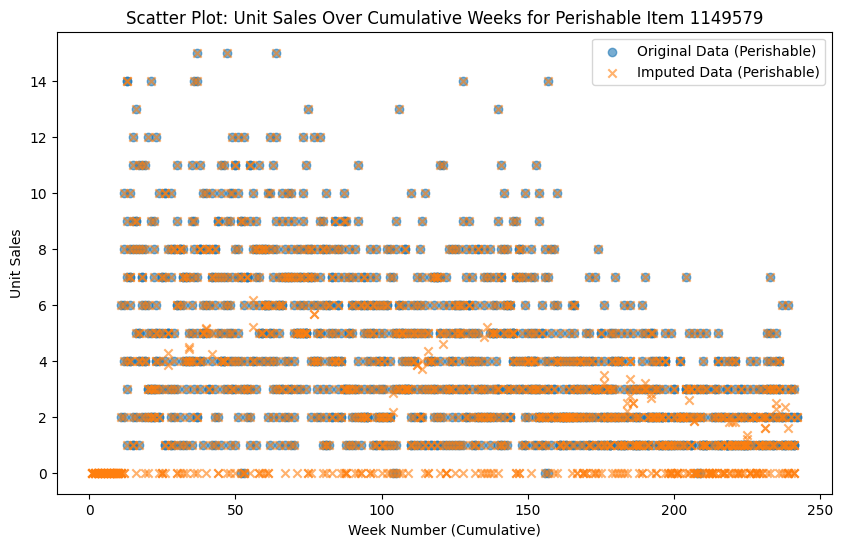

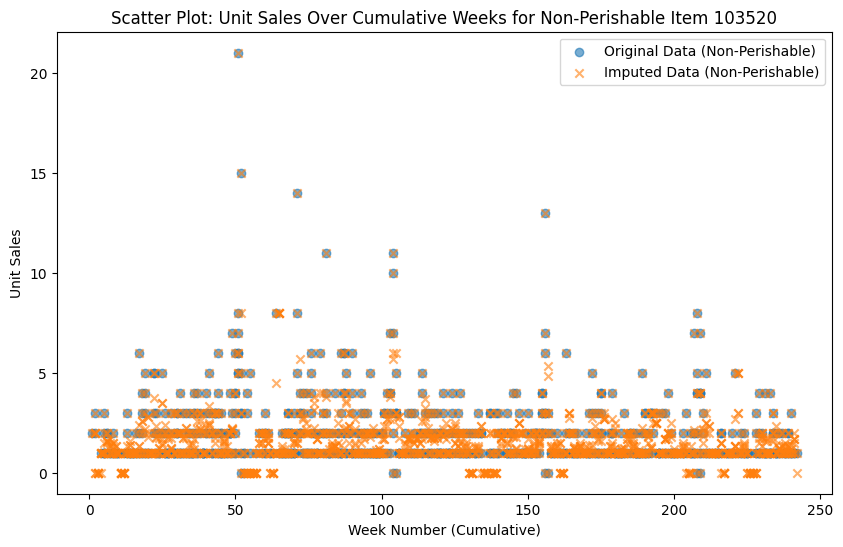

In [95]:
plot_scatter_perishable(df_final_10_103520_1149579, df_final_10_103520_1149579_imputed)
plot_scatter_non_perishable(
    df_final_10_103520_1149579, df_final_10_103520_1149579_imputed
)

In [ ]:
def stop

### 3.2. Aggregate dataset to weekly level

- Group the DataFrame by store number, item number, year, and week_cum_number, then aggregate the columns
--> "unit_sales","onpromotion", "holiday_local_count","holiday_regional_count","holiday_national_count",


In [ ]:
def aggregate_week(df):

    # Sort the DataFrame by store number, item number, and date for ordering
    df = df.sort_values(["store_nbr", "item_nbr", "year", "week_nbr"])

    # Group by the specified columns and aggregate
    df = (
        df.groupby(
            [
                "store_nbr",
                "item_nbr",
                "year",
                "week_number_cum",  # Aggregating by week_number_cum
            ]
        )
        .agg(
            {
                "unit_sales": "sum",
                "onpromotion": "sum",
                "holiday_local_count": "sum",
                "holiday_regional_count": "sum",
                "holiday_national_count": "sum",
                "date": "first",  # Keep the first day of week, needed to run Timeseries models from SKtime
                "store_type": "first",  # Keep the first occurrence of store_type
                "store_cluster": "first",  # Keep the first occurrence of store_cluster
                "item_family": "first",  # Keep the first occurrence of item_family
                "item_class": "first",  # Keep the first occurrence of item_class
                "perishable": "first",  # Keep the first occurrence of perishable
                "store_status": "last",  # Keep the last occurrence of store_status
                "item_status": "last",  # Keep the last occurrence of item_status
            }
        )
        .reset_index()
    )

    return df

## 4. Pipeline and preprocessing

Splitting and preprocessing with imputation and aggregating to weekly data

In [ ]:
features = [
    "date",
    "store_nbr",
    "item_nbr",  # , 'item_family', 'store_type', 'perishable'
]


target_variable = ["unit_sales"]

In [ ]:
def impute_agg_preprocessing(df, window_size=7):

    df = impute_stockouts_polars(df, window_size)

    df = aggregate_week(df)

    return df

In [ ]:
def preprocess_split_filter(df, features, target_variable):

    # Splitting in train, validation, test split
    print(f"\nStep 1: Splitting in train, validation, test split")
    train_df, val_df, test_df = train_val_test_split(df)

    # Preprocessing with imputation and aggregating to weekly data
    print(f"\nStep 2: Preprocessing with imputation and aggregating to weekly data")
    train_df = impute_agg_preprocessing(train_df)
    val_df = impute_agg_preprocessing(val_df)
    test_df = impute_agg_preprocessing(test_df)

    # Filter spilts on needed feature and target variables
    print(f"\nStep 3: Filter spilts on needed feature and target variables")
    train_df = train_df[features + target_variable]
    val_df = val_df[features + target_variable])
    test_df = test_df[features + target_variable]

    # Ensure df's are sorted by store, item, and date for alignment
    print(f"\nStep 4: Ensure dfs are sorted by store, item, and date for alignment")
    train_df = train_df.sort_values(by=["store_nbr", "item_nbr", "date"])
    val_df = val_df.sort_values(by=["store_nbr", "item_nbr", "date"])
    test_df = test_df.sort_values(by=["store_nbr", "item_nbr", "date"])

    return train_df, val_df, test_df

In [ ]:
train_df, val_df, test_df = preprocess_split_filter(df_final, features, target_variable)


Step 1: Splitting in train, validation, test split

Train set: shape: (46461408, 19)
Train Min Week: 1
Train Max Week: 190
Train number of weeks: 190
Number of stores: 42
Number of items: 833
Size of 1.86 GB.

Validation set: shape: (6367452, 19)
Validation Min Week: 191
Validation Max Week: 216
Validation number of weeks: 26
Number of stores: 42
Number of items: 833
Size of 0.25 GB.

Test set: shape: (6192522, 19)
Test Min Week: 217
Test Max Week: 242
Test number of weeks: 26
Number of stores: 42
Number of items: 833
Size of 0.25 GB.

Step 2: Preprocessing with imputation and aggregating to weekly data
Size of train_df0.25 GB.
Size of val_df0.03 GB.
Size of test_df0.03 GB.

Step 3: Filter spilts on needed feature and target variables
Size of train_df0.11 GB.
Size of val_df0.01 GB.
Size of test_df0.01 GB.

Step 4: Ensure dfs are sorted by store, item, and date for alignment
Size of train_df0.11 GB.
Size of val_df0.01 GB.
Size of test_df0.01 GB.


In [ ]:
def null_count(df):  # Count nulls per column
    null_counts = df.isnull().sum()

    # Print results
    for column, count in null_counts.items():
        print(f"Column '{column}' has {count} null values.")

    return

In [ ]:
null_count(train_df)

Column 'date' has 0 null values.
Column 'store_nbr' has 0 null values.
Column 'item_nbr' has 0 null values.
Column 'unit_sales' has 0 null values.


In [ ]:
df_final.head(5)

,store_nbr,item_nbr,date,unit_sales,onpromotion,holiday_local_count,holiday_national_count,holiday_regional_count,store_type,store_cluster,item_family,item_class,perishable,store_status,item_status,year,weekday,week_nbr,week_number_cum
0,1,103520,2013-01-02,NaN,False,0,0,0,D,13,GROCERY I,1028,0,0,3,2013,3,1,1
44646455,41,1441517,2013-01-02,NaN,False,0,0,0,D,4,GROCERY I,1008,0,0,3,2013,3,1,1
44644768,41,1441516,2013-01-02,NaN,False,0,0,0,D,4,GROCERY I,1008,0,0,3,2013,3,1,1
5393339,4,1963540,2013-01-02,NaN,False,0,0,0,D,9,GROCERY I,1040,0,0,3,2013,3,1,1
44643081,41,1441515,2013-01-02,NaN,False,0,0,0,D,4,GROCERY I,1008,0,0,3,2013,3,1,1


### Write to Parquet fil and saves it in output_path

In [ ]:
def save_dataframe_to_parquet(df, output_path, file_prefix="Prepped_data"):
    try:
        # Ensure the directory exists
        os.makedirs(output_path, exist_ok=True)

        # Generate today's date for the filename
        today = date.today().strftime("%Y%m%d")

        # Create the full filename with path
        filename = f"{file_prefix}_{today}.parquet"
        full_path = os.path.join(output_path, filename)

        # Save the DataFrame to a Parquet file
        df.to_parquet(full_path)

        print(f"DataFrame successfully saved to {full_path}")

        return full_path

    except Exception as e:
        print(f"Error saving DataFrame to Parquet file: {e}")

        return None

In [ ]:
def save_dataframe_to_csv(df, output_path, file_prefix="Prepped_data"):
    try:
        # Ensure the directory exists
        os.makedirs(output_path, exist_ok=True)

        # Generate today's date for the filename
        today = date.today().strftime("%Y%m%d")

        # Create the full filename with path
        filename = f"{file_prefix}_{today}.csv"
        full_path = os.path.join(output_path, filename)

        # Save the DataFrame to a CSV file
        df.to_csv(full_path, index=False)

        print(f"DataFrame successfully saved to {full_path}")

        return full_path

    except Exception as e:
        print(f"Error saving DataFrame to CSV file: {e}")

        return None

In [ ]:
get_columns(df_final)

['store_nbr',
 'item_nbr',
 'date',
 'unit_sales',
 'onpromotion',
 'holiday_local_count',
 'holiday_national_count',
 'holiday_regional_count',
 'store_type',
 'store_cluster',
 'item_family',
 'item_class',
 'perishable',
 'store_status',
 'item_status',
 'year',
 'weekday',
 'week_nbr',
 'week_number_cum']

In [ ]:
output_path = "C:/Users/alexander/Documents/0. Data Science and AI for Experts/FILE"

In [ ]:
train_df_saved_path = save_dataframe_to_parquet(
    train_df, output_path, file_prefix="train_df_holt"
)

DataFrame successfully saved to C:/Users/alexander/Documents/0. Data Science and AI for Experts/FILE\train_df_holt_20241115.parquet


In [ ]:
val_df_saved_path = save_dataframe_to_parquet(
    val_df, output_path, file_prefix="val_df_holt"
)

DataFrame successfully saved to C:/Users/alexander/Documents/0. Data Science and AI for Experts/FILE\val_df_holt_20241115.parquet


In [ ]:
test_df_saved_path = save_dataframe_to_parquet(
    test_df, output_path, file_prefix="test_df_holt"
)

DataFrame successfully saved to C:/Users/alexander/Documents/0. Data Science and AI for Experts/FILE\test_df_holt_20241115.parquet


In [ ]:
def stop

SyntaxError: expected '(' (137546471.py, line 1)

## 5. Model Pipeline

### 5.1 Model: Holt-Winters

In [ ]:
# holt_winters_model = ExponentialSmoothing(
#     df_train, trend="add", seasonal="add", seasonal_periods=12
# ).fit()

#                   .fit(smoothing_level=0.5, #=best_alpha
#                        smoothing_slope=0.5, #=best_beta
#                        smoothing_seasonal=0.5) #=best_gamma

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)  # Suppress Warnings

### 5.2 Run Model

In [ ]:
def holt_winters_model_forecast(
    train_df, val_df, seasonal_periods=13, trend="add", seasonal="add"
):
    # Unique store and item combinations
    unique_stores = train_df["store_nbr"].unique()
    unique_items = train_df["item_nbr"].unique()

    forecasts = {}

    for store in unique_stores:
        print(
            f"Model Holly starts training with Winnie by forecasting for store {store}"
        )
        for item in unique_items:
            # Filter the data for the specific store and item
            train_data = train_df[
                (train_df["store_nbr"] == store) & (train_df["item_nbr"] == item)
            ].copy()

            # Convert date to datetime and set as index
            train_data["date"] = pd.to_datetime(train_data["date"])
            train_data.set_index("date", inplace=True)
            train_data = train_data.asfreq("W")  # Setting frequency to weekly

            # Extract the unit_sales series
            train_series = train_data["unit_sales"].copy()

            # Fit Holt-Winters Model
            try:
                model = ExponentialSmoothing(
                    train_series,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=seasonal_periods,
                )
                fitted_model = model.fit()

                # Forecast the validation period length
                forecast_length = len(
                    val_df[
                        (val_df["store_nbr"] == store) & (val_df["item_nbr"] == item)
                    ]["date"].unique()
                )
                if forecast_length <= 0:
                    print(
                        f"Skipping forecast for store {store}, item {item} due to zero or negative forecast length."
                    )
                    continue

                print(
                    f"Forecast Length for store {store}, item {item}: {forecast_length}"
                )

                forecast = fitted_model.forecast(forecast_length)

                # Store the forecast
                forecasts[(store, item)] = forecast

            except Exception as e:
                print(f"Model failed for store {store}, item {item}: {e}")

    return forecasts

In [ ]:
train_df_store_1 = train_df[train_df["store_nbr"] == 1]

val_df_store_1 = val_df[val_df["store_nbr"] == 1]

In [ ]:
train_df_store_1_103520 = train_df_store_1[train_df_store_1["item_nbr"] == 103520]

val_df_store_1_103520 = val_df_store_1[val_df_store_1["item_nbr"] == 103520]

In [ ]:
print(train_df_store_1_103520.shape)
print(val_df_store_1_103520.shape)

(190, 4)
(26, 4)


In [ ]:
forecast_predictions = holt_winters_model_forecast(
    train_df_store_1_103520,
    val_df_store_1_103520,
    seasonal_periods=26,
    trend="add",
    seasonal="add",
)

Model Holly starts training with Winnie by forecasting for store 1
Model failed for store 1, item 103520: shapes (2,10) and (0,1) not aligned: 10 (dim 1) != 0 (dim 0)


c:\Users\alexander\Documents\0. Data Science and AI for Experts\EAISI_4B_Supermarket\venv_case_project\Lib\site-packages\statsmodels\tsa\exponential_smoothing\initialization.py:95: RuntimeWarning: Mean of empty slice
  initial_seasonal = np.nanmean(


In [ ]:
def holt_winters_model_forecast_github(
    train_df, val_df, seasonal_periods=, trend="add", seasonal="add"
):

    # Convert the input Pandas DataFrame to a Polars DataFrame
    train_df = pl.from_pandas(train_df)
    val_df = pl.from_pandas(test_df)

    unique_stores = train_df["store_nbr"].unique()
    unique_items = train_df["item_nbr"].unique()

    forecasts = {}

    for store in unique_stores:
        print(
            f"Model Holly starts training with Winnie by forecasting for store {store}"
        )
        for item in unique_items:
            # Filter the data for the specific store and item using polars filtering
            train_data = train_df.filter(
                (pl.col("store_nbr") == store) & (pl.col("item_nbr") == item)
            )
            train_data = train_data.sort("date")

            # Convert Polars DataFrame to Pandas (needed for statsmodels, as it only runs in pandas)
            # Set index on date for unit_sales, per unique store, per item
            train_series = train_data.to_pandas().set_index("date")["unit_sales"]

            # Convert to weekly frequency
            #train_series = train_series.asfreq('W')

            # Fit Holt Winters Model
            try:
                model = ExponentialSmoothing(
                    train_series,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=seasonal_periods,
                )
                fitted_model = model.fit()

                # Forecast the validation period length
                forecast_length = len(
                    val_df.filter(pl.col("store_nbr") == store)["date"].unique()
                )
                forecast = fitted_model.forecast(forecast_length)

                # Store the forecast in a dictionary for future reference
                forecasts[(store, item)] = forecast

            except Exception as e:
                print(f"Model failed for store {store} item {item}: {e}")

    return forecasts

In [ ]:
forecast_predictions = holt_winters_model_forecast_github(
    train_df_store_1_103520,
    val_df_store_1_103520,
    seasonal_periods=13,
    trend="add",
    seasonal="add",
)

Model Holly starts training with Winnie by forecasting for store 1


c:\Users\alexander\Documents\0. Data Science and AI for Experts\EAISI_4B_Supermarket\venv_case_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\alexander\Documents\0. Data Science and AI for Experts\EAISI_4B_Supermarket\venv_case_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\alexander\Documents\0. Data Science and AI for Experts\EAISI_4B_Supermarket\venv_case_project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

In [ ]:
forecast_predictions = holt_winters_model_forecast_github(
    train_df_1, val_df_1, seasonal_periods=13, trend="add", seasonal="add"
)  # --> Takes 85 minutes for 10 stores

In [ ]:
train_df.head(10)

### 5.3. Evaulation Metrics and Evaluate Model functions

In [ ]:
def calculate_metrics(y_true, y_pred):

    # if len(y_true) == 0 or len(y_pred) == 0:
    #     return {"MAPE": np.nan, "Accuracy": np.nan, "Bias": np.nan}

    mape = mean_absolute_percentage_error(y_true, y_pred)

    accuracy = 1 - mape

    bias = np.mean(y_pred - y_true)

    return {"MAPE": mape, "Accuracy": accuracy, "Bias": bias}

In [ ]:
def evaluate_forecasts(forecasts, val_df):

    # Initialize lists to store metrics for each store and item
    all_metrics = []
    store_metrics = []

    # Ensure val_df is sorted by store, item, and date for accurate alignment
    # val_df = val_df.sort_values(by=["store_nbr", "item_nbr", "date"])

    # Iterate over each store and item combination to collect true and predicted values
    for (store, item), forecast in forecasts.items():

        y_true = val_df[(val_df["store_nbr"] == store) & (val_df["item_nbr"] == item)][
            "unit_sales"
        ]
        y_pred = forecast

        # Index the values
        # y_true = y_true.reset_index(drop=True)
        # y_pred = pd.Series(forecast).reset_index(drop=True)

        if len(y_true) == len(y_pred):
            metrics = calculate_metrics(y_true, y_pred)
            metrics.update({"store_nbr": store, "item_nbr": item})
            all_metrics.append(metrics)

            if store not in store_metrics:
                store_metrics[store] = {"MAPE": [], "Accuracy": [], "Bias": []}
            store_metrics[store]["MAPE"].append(metrics["MAPE"])
            store_metrics[store]["Accuracy"].append(metrics["Accuracy"])
            store_metrics[store]["Bias"].append(metrics["Bias"])

    # Calculate average metrics for each store
    average_store_metrics = []
    for store, metrics in store_metrics.items():
        average_mape = np.nanmean(metrics["MAPE"])
        average_accuracy = np.nanmean(metrics["Accuracy"])
        average_bias = np.nanmean(metrics["Bias"])

        average_store_metrics.append(
            {
                "store_nbr": store,
                "item_nbr": "average",
                "MAPE": average_mape,
                "Accuracy": average_accuracy,
                "Bias": average_bias,
            }
        )

    # Calculate overall average metrics
    overall_mape = np.nanmean(
        [metric["MAPE"] for metric in all_metrics if not np.isnan(metric["MAPE"])]
    )
    overall_accuracy = np.nanmean(
        [
            metric["Accuracy"]
            for metric in all_metrics
            if not np.isnan(metric["Accuracy"])
        ]
    )
    overall_bias = np.nanmean(
        [metric["Bias"] for metric in all_metrics if not np.isnan(metric["Bias"])]
    )

    overall_metrics = {
        "store_nbr": "overall",
        "item_nbr": "overall",
        "MAPE": overall_mape,
        "Accuracy": overall_accuracy,
        "Bias": overall_bias,
    }

    # Convert metrics to df's
    metrics_df = pd.DataFrame(all_metrics)
    average_store_metrics_df = pd.DataFrame(average_store_metrics)
    overall_metrics_df = pd.DataFrame([overall_metrics])

    # Print metrics
    # print(metrics_df)
    # print(average_store_metrics_df)
    print(overall_metrics_df)

    return metrics_df, average_store_metrics_df, overall_metrics_df

In [ ]:
# Evaluate forecasts and print metrics
metrics_df, average_store_metrics_df, overall_metrics_df = evaluate_forecasts(
    forecast_predictions, val_df
)

IndexError: list assignment index out of range

In [ ]:
overall_metrics_df

In [ ]:
average_store_metrics_df

In [ ]:
metrics_df.sort_values(by="MAPE", ascending=True).head(50)

-------------------------------------------

## 6. Hyperparameter Optimization (Grid Search approach)

https://www.kaggle.com/code/mehmetisik/smoothing-methods-holt-winters/notebook#Final-TES-Model

- alpha: smoothing level for the level components
- beta: smoothing level for the trend components
- gamma: smoothing level for the seasonal components

--> Problem, bc goining to test for every store-item combination multiple alpha, beta, and gamma. So gpu Parallel Processing needed probably

In [ ]:
DEF STOP

In [ ]:
# Create a range of values for alpha, beta, and gamma
alphas = betas = gammas = np.arange(0.20, 1, 0.10)

In [ ]:
import itertools

# create all combinations of alpha, beta, and gamma
abg = list(itertools.product(alphas, betas, gammas))

In [ ]:
def hw_model_optimizer(df_train, abg, step=24):

    best_alpha, best_beta, best_gamma, best_mape = None, None, None, float("inf")

    for comb in abg:

        model = ExponentialSmoothing(
            df_train, trend="add", seasonal="add", seasonal_periods=12
        ).fit(
            smoothing_level=comb[0], smoothing_slope=comb[1], smoothing_seasonal=comb[2]
        )

        y_pred = model.forecast(step)
        mape = mean_absolute_percentage_error(df_train[-step:], y_pred)
        if mape < best_mape:
            best_alpha, best_beta, best_gamma, best_mape = (
                comb[0],
                comb[1],
                comb[2],
                mape,
            )
        print([round(comb[0], 2), round(comb[1], 2), round(comb[2], 2), round(mape, 2)])

    print(
        "best_alpha:",
        round(best_alpha, 2),
        "best_beta:",
        round(best_beta, 2),
        "best_gamma:",
        round(best_gamma, 2),
        "best_mae:",
        round(best_mape, 4),
    )

    return best_alpha, best_beta, best_gamma, best_mape

In [ ]:
best_alpha, best_beta, best_gamma, best_mae = hw_model_optimizer(df_train, abg)

In [ ]:
final_tes_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=12
).fit(
    smoothing_level=best_alpha, smoothing_trend=best_beta, smoothing_seasonal=best_gamma
)

Parallel Processing for item forecasts in parallel for each unique store


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_absolute_percentage_error
from concurrent.futures import ProcessPoolExecutor, as_completed


def holt_winters_model_forecast(
    train_df,
    val_df,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    early_stopping_threshold=0.01,
    max_no_improve_iters=5,
):
    # Unique store and item combinations
    unique_stores = train_df["store_nbr"].unique()
    unique_items = train_df["item_nbr"].unique()

    # Create a range of values for alpha, beta, and gamma
    alphas = betas = gammas = np.arange(0.20, 1, 0.10)
    abg_combinations = list(itertools.product(alphas, betas, gammas))

    forecasts = {}
    best_params = (
        {}
    )  # Dictionary to store the best alpha, beta, gamma for each (store, item)

    def process_item(store, item):
        result = None
        # Filter the data for the specific store and item
        train_data = train_df[
            (train_df["store_nbr"] == store) & (train_df["item_nbr"] == item)
        ].copy()
        val_data = val_df[
            (val_df["store_nbr"] == store) & (val_df["item_nbr"] == item)
        ].copy()

        # Convert date to datetime and set as index
        train_data["date"] = pd.to_datetime(train_data["date"])
        train_data.set_index("date", inplace=True)
        train_data = train_data.asfreq("W")  # Setting frequency to weekly

        val_data["date"] = pd.to_datetime(val_data["date"])
        val_data.set_index("date", inplace=True)
        val_data = val_data.asfreq("W")

        # Extract the unit_sales series
        train_series = train_data["unit_sales"].copy()
        val_series = val_data["unit_sales"].copy()

        # Optimize alpha, beta, gamma with early stopping
        best_alpha, best_beta, best_gamma, best_mape = None, None, None, float("inf")
        no_improve_count = 0

        for comb in abg_combinations:
            try:
                model = ExponentialSmoothing(
                    train_series,
                    trend=trend,
                    seasonal=seasonal,
                    seasonal_periods=seasonal_periods,
                )
                fitted_model = model.fit(
                    smoothing_level=comb[0],
                    smoothing_slope=comb[1],
                    smoothing_seasonal=comb[2],
                )

                # Forecast the validation period length
                forecast_length = len(val_series)
                y_pred = fitted_model.forecast(forecast_length)
                mape = mean_absolute_percentage_error(
                    val_series, y_pred[: len(val_series)]
                )

                if mape < best_mape:
                    best_alpha, best_beta, best_gamma, best_mape = (
                        comb[0],
                        comb[1],
                        comb[2],
                        mape,
                    )
                    no_improve_count = 0  # Reset counter if improvement found
                else:
                    no_improve_count += 1

                # Early stopping if no improvement for max_no_improve_iters iterations
                if no_improve_count >= max_no_improve_iters:
                    print(
                        f"Early stopping for store {store}, item {item} due to no improvement."
                    )
                    break

            except Exception as e:
                print(
                    f"Failed to fit model for store {store}, item {item} with parameters {comb}: {e}"
                )
                continue

        if best_alpha is None:
            print(f"Could not find suitable parameters for store {store}, item {item}.")
            return result

        # Fit the model with the best parameters
        try:
            model = ExponentialSmoothing(
                train_series,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=seasonal_periods,
            )
            fitted_model = model.fit(
                smoothing_level=best_alpha,
                smoothing_slope=best_beta,
                smoothing_seasonal=best_gamma,
            )

            forecast = fitted_model.forecast(len(val_series))

            # Store the forecast in a dictionary for future reference
            result = ((store, item), forecast)

            # Store the best parameters for the current (store, item)
            best_params[(store, item)] = {
                "alpha": best_alpha,
                "beta": best_beta,
                "gamma": best_gamma,
                "mape": best_mape,
            }

        except Exception as e:
            print(
                f"Model failed for store {store}, item {item} with best parameters: {e}"
            )

        return result

    with ProcessPoolExecutor() as executor:
        future_to_store_item = {
            executor.submit(process_item, store, item): (store, item)
            for store in unique_stores
            for item in unique_items
        }

        for future in as_completed(future_to_store_item):

            store_item = future_to_store_item[future]

            try:
                result = future.result()

                if result:

                    forecasts[result[0]] = result[1]

            except Exception as e:
                print(
                    f"Exception occurred for store {store_item[0]}, item {store_item[1]}: {e}"
                )

    return forecasts, best_params

In [ ]:
forecasts, best_params = holt_winters_model_forecast(train_df, val_df)

In [ ]:
# Evaluate forecasts and print metrics
metrics_df, average_store_metrics_df, overall_metrics_df = evaluate_forecasts(
    forecasts, val_df
)